In [4]:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


3. Analisi vendite (dataset tips)

Esegui un’analisi esplorativa focalizzata sulle vendite giornaliere.
Analizza i seguenti aspetti per ogni giorno (day):

3.1 Il conto medio (total_bill)

In [9]:
conto_medio = df.groupby("day")["total_bill"].mean()

print(conto_medio)

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64


3.2 Il numero totale di osservazioni (conteggio delle righe)

In [10]:
oss = df.groupby("day").size()

print(oss)

day
Fri     19
Sat     87
Sun     76
Thur    62
dtype: int64


3.3 Il valore minimo e massimo del conto (total_bill → min / max)

In [11]:
min = df.groupby("day")["total_bill"].min()
max = df.groupby("day")["total_bill"].max()

result = pd.concat([min, max], axis=1)
print(result)

      total_bill  total_bill
day                         
Fri         5.75       40.17
Sat         3.07       50.81
Sun         7.25       48.17
Thur        7.51       43.11


3.4 Crea una nuova colonna conto_per_persona che sia:
total_bill / size

In [ ]:
df["conto_per_persona"] = df["total_bill"]/df["size"].replace(0, pd.NA)

print(df)

     total_bill   tip     sex smoker   day    time  size  conto_per_persona
0         16.99  1.01  Female     No   Sun  Dinner     2           8.495000
1         10.34  1.66    Male     No   Sun  Dinner     3           3.446667
2         21.01  3.50    Male     No   Sun  Dinner     3           7.003333
3         23.68  3.31    Male     No   Sun  Dinner     2          11.840000
4         24.59  3.61  Female     No   Sun  Dinner     4           6.147500
..          ...   ...     ...    ...   ...     ...   ...                ...
239       29.03  5.92    Male     No   Sat  Dinner     3           9.676667
240       27.18  2.00  Female    Yes   Sat  Dinner     2          13.590000
241       22.67  2.00    Male    Yes   Sat  Dinner     2          11.335000
242       17.82  1.75    Male     No   Sat  Dinner     2           8.910000
243       18.78  3.00  Female     No  Thur  Dinner     2           9.390000

[244 rows x 8 columns]


3.5 Trova il giorno con il conto medio più alto

In [21]:
print(conto_medio[conto_medio == conto_medio.max()])

day
Sun    21.41
Name: total_bill, dtype: float64


Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre.
Ordina i dati dal valore più alto al più basso.
Aggiungi titolo ed etichette agli assi.

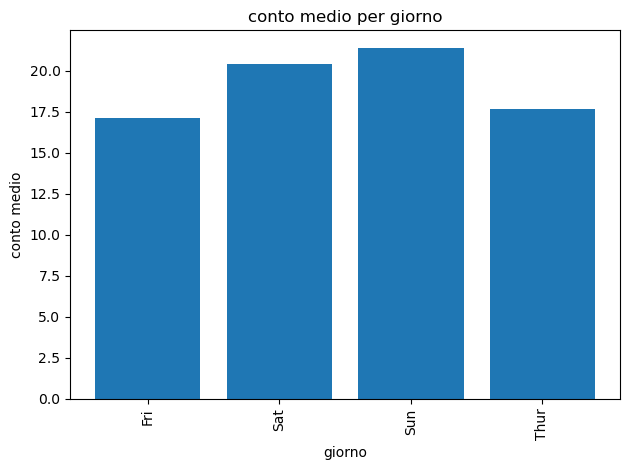

In [33]:
import matplotlib.pyplot as plt


plt.figure()
plt.bar(conto_medio.index, conto_medio.values)

plt.xlabel("giorno")
plt.ylabel("conto medio")
plt.title("conto medio per giorno")

# Ruota le etichette per leggibilità
plt.xticks(rotation=90)

# Layout migliore
plt.tight_layout()

# Mostra il grafico
plt.show()